# 02 — Missing Value Analysis
**Hotel Booking Demand Dataset**

This notebook identifies, quantifies, and visualises all missing data in the dataset, then proposes a handling strategy for each affected column.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


In [2]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset shape: 119,390 rows × 32 columns


## 1 — Missing Value Counts per Column

In [3]:
missing_counts = df.isnull().sum()
missing_only   = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_only.to_string())


Columns with missing values:
company     112593
agent        16340
country        488
children         4


## 2 — Percentage of Missing Values per Column

In [4]:
total_rows      = len(df)
missing_pct     = (missing_counts / total_rows * 100).round(4)
missing_summary = pd.DataFrame({
    "missing_count"  : missing_counts,
    "missing_pct_%"  : missing_pct,
    "present_count"  : total_rows - missing_counts,
    "present_pct_%"  : (100 - missing_pct).round(4)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0] \
                    .sort_values("missing_count", ascending=False)

print(f"Total rows: {total_rows:,}\n")
missing_summary


Total rows: 119,390



,missing_count,missing_pct_%,present_count,present_pct_%
company,112593,94.3069,6797,5.6931
agent,16340,13.6862,103050,86.3138
country,488,0.4087,118902,99.5913
children,4,0.0034,119386,99.9966


## 3 — Visualising Missing Values

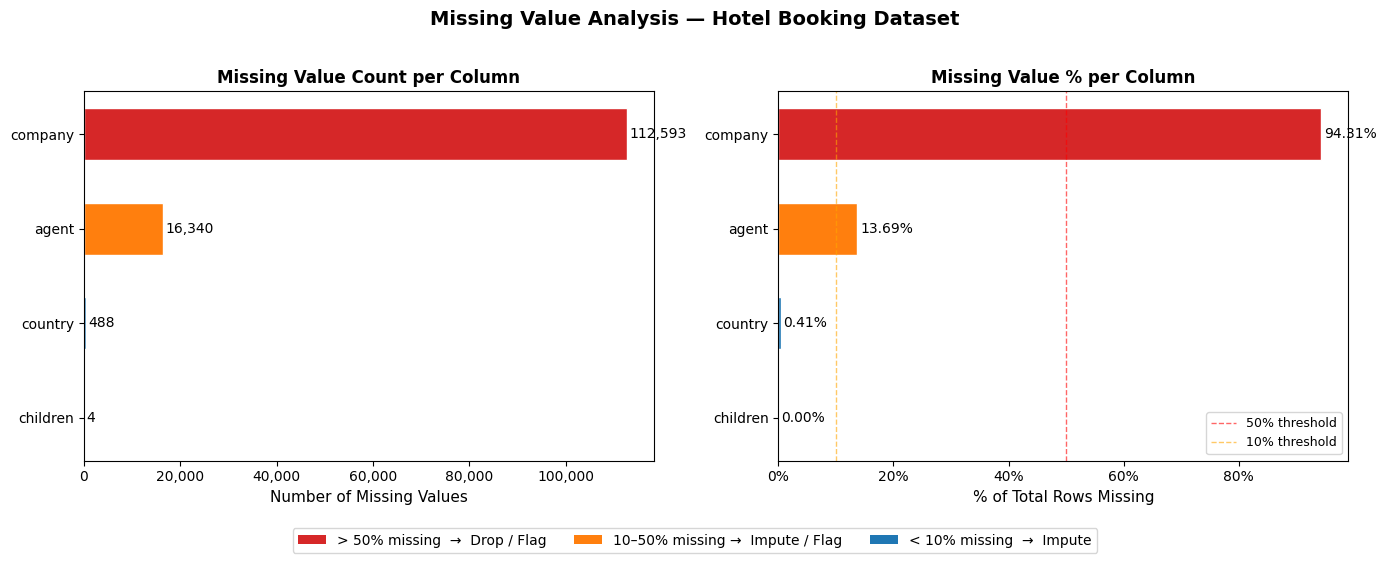

Chart saved to visuals/missing_values_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Missing Value Analysis — Hotel Booking Dataset",
             fontsize=14, fontweight="bold", y=1.02)

cols   = missing_summary.index.tolist()
counts = missing_summary["missing_count"].values
pcts   = missing_summary["missing_pct_%"].values

# ── Plot 1: Raw counts ──────────────────────────────────────────────────────
colors = ["#d62728" if p > 50 else "#ff7f0e" if p > 10 else "#1f77b4" for p in pcts]
bars1  = axes[0].barh(cols, counts, color=colors, edgecolor="white", height=0.55)
axes[0].set_xlabel("Number of Missing Values", fontsize=11)
axes[0].set_title("Missing Value Count per Column", fontsize=12, fontweight="bold")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars1, counts):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=10)

# ── Plot 2: Percentages ─────────────────────────────────────────────────────
bars2 = axes[1].barh(cols, pcts, color=colors, edgecolor="white", height=0.55)
axes[1].set_xlabel("% of Total Rows Missing", fontsize=11)
axes[1].set_title("Missing Value % per Column", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].axvline(x=50, color="red",    linestyle="--", linewidth=1, alpha=0.6, label="50% threshold")
axes[1].axvline(x=10, color="orange", linestyle="--", linewidth=1, alpha=0.6, label="10% threshold")
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, pcts):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}%", va="center", fontsize=10)

# ── Legend annotation ───────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="> 50% missing  →  Drop / Flag"),
    Patch(facecolor="#ff7f0e", label="10–50% missing →  Impute / Flag"),
    Patch(facecolor="#1f77b4", label="< 10% missing  →  Impute"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("../visuals/missing_values_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved to visuals/missing_values_analysis.png")


## 4 — Top 3 Most Critical Columns with Missing Data

In [6]:
critical_cols = ["company", "agent", "country", "children"]

print("=" * 60)
for col in critical_cols:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f"  {col:<12}  missing: {n:>7,}  ({pct:.2f}%)")
    if col in ["company", "agent"]:
        filled = df[col].notna().sum()
        print(f"             filled : {filled:>7,}  ({100-pct:.2f}%)")
    print()
print("=" * 60)

# Show value distribution for non-null agent/company entries
print("\nAgent — unique non-null values :", df["agent"].nunique())
print("Company — unique non-null values:", df["company"].nunique())
print("Country — unique non-null values:", df["country"].nunique())
print("Children — value counts (top 5):")
print(df["children"].value_counts().head())


  company       missing: 112,593  (94.31%)
             filled :   6,797  (5.69%)

  agent         missing:  16,340  (13.69%)
             filled : 103,050  (86.31%)

  country       missing:     488  (0.41%)

  children      missing:       4  (0.00%)


Agent — unique non-null values : 333
Company — unique non-null values: 352
Country — unique non-null values: 177
Children — value counts (top 5):
children
0.0000     110796
1.0000       4861
2.0000       3652
3.0000         76
10.0000         1
Name: count, dtype: int64


## 5 — Missing Data Analysis & Handling Strategy

---

### 5.1 Which Columns Have Missing Data?

Only **4 columns** contain missing values out of 32:

| Column | Missing Count | Missing % | Severity |
|--------|--------------|-----------|----------|
| `company` | 112,593 | **94.31%** | 🔴 Critical |
| `agent` | 16,340 | **13.69%** | 🟠 Moderate |
| `country` | 488 | **0.41%** | 🟡 Low |
| `children` | 4 | **0.003%** | 🟢 Negligible |

---

### 5.2 Is the Missing Data Random or Systematic?

#### `company` — 94.31% missing → **Systematic (MNAR)**
> Missing **Not At Random**. The overwhelming majority of hotel guests are individual travellers or leisure tourists, not corporate accounts. A `NULL` company ID is not a data error — it structurally means *"this booking was not made via a corporate account."* The missingness is an inherent business characteristic of the data.

#### `agent` — 13.69% missing → **Systematic (MNAR)**
> Also **Not At Random**. A `NULL` agent ID means the booking was made **directly** (no travel agency involved). This is a meaningful signal — direct bookings may behave differently in terms of cancellation rates and ADR. Missingness carries information.

#### `country` — 0.41% missing → **Random (MAR)**
> Likely **Missing At Random**. Country is typically self-reported during booking; 488 guests simply did not provide it. No strong systematic pattern expected. This is a low-impact column for most analyses.

#### `children` — 0.003% missing → **Random (MCAR)**
> Almost certainly **Missing Completely At Random** — only 4 rows affected. Likely a data entry omission with no systematic cause.

---

### 5.3 Proposed Handling Strategy

| Column | Strategy | Rationale |
|--------|----------|-----------|
| `company` | **Create binary flag** `has_company` (1/0), then **fill NaN → 0** | 94% missing means the column can't be used as-is. A flag captures the key signal (corporate vs. non-corporate) without fabricating IDs. Dropping the column loses information. |
| `agent` | **Create binary flag** `has_agent` (1/0), then **fill NaN → 0** | Same logic — direct bookings (no agent) are a meaningful business segment. Flag preserves the signal; filling with 0 avoids issues in numeric models. |
| `country` | **Impute with mode** (`"PRT"` — Portugal, the most frequent country) | < 0.5% missing; mode imputation introduces minimal bias. Alternatively, impute with `"Unknown"` for categorical models that support it. |
| `children` | **Impute with 0** (integer) | Only 4 rows; 0 children is by far the most common value (96%+ of guests). Safe median/mode imputation with negligible impact. |

---

### 5.4 Implementation Plan (Next Notebook)

```python
# Flag-based handling for company & agent
df["has_company"] = df["company"].notna().astype(int)
df["has_agent"]   = df["agent"].notna().astype(int)
df["company"]     = df["company"].fillna(0)
df["agent"]       = df["agent"].fillna(0)

# Impute country with mode
df["country"]     = df["country"].fillna(df["country"].mode()[0])

# Impute children with 0
df["children"]    = df["children"].fillna(0).astype(int)
```

> These transformations will be applied in `03_data_cleaning.ipynb`.
